# Nonconforming LCG MMS convergence - 2D point trace

This notebook is copied from the manual 2D point-trace LCG workflow, but reduced to the MMS reference solve and convergence test.  It avoids the pseudo-3D slab and `fenicsx_ii` circle-average restriction: the independent 1D fracture is coupled to the 2D bulk by direct point-trace quadrature.

Default setup: P1 bulk/fracture pressure spaces and a P1 multiplier with `h_Gamma ~= h/2` and `h_lambda ~= 3h`, for testing a coarser independent multiplier mesh in the direct point-trace notebook.  The final convergence plot is shown for any polynomial order.


In [1]:
from mpi4py import MPI
from petsc4py import PETSc
import pathlib
import time

import numpy as np
import matplotlib.pyplot as plt
import ufl
import basix.ufl
from dolfinx import fem, mesh

comm = MPI.COMM_WORLD
rank = comm.rank
if comm.size != 1:
    raise RuntimeError("This manual point-trace assembly notebook is serial; run it with one MPI rank.")

# Convergence controls.
RUN_CONVERGENCE = True
CONV_REFS = list(range(2, 9))
CONV_TIP_FRAC = 0.1
CONV_PLOT = True

# P1/P1 mesh-ratio test: refined fracture pressure mesh and coarser multiplier mesh.
# h_Gamma ~= h/2 and h_lambda ~= 3h.
PRESSURE_ORDER = 2
MULTIPLIER_ORDER = 1
FEM_ORDER = PRESSURE_ORDER  # Backward-compatible alias if later cells are added.

# Alternative Koppel-Martin-style low-order check:
# PRESSURE_ORDER = 1
# MULTIPLIER_ORDER = 0
# FRACTURE_PRESSURE_LC_FACTOR = 0.5
# MULTIPLIER_LC_FACTOR = 2.0

# MMS parameters.
ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

# Full diagonal MMS fracture, matching the nonconforming MMS notebook.
FRAC_A = np.array([0.0, 0.0], dtype=float)
FRAC_B = np.array([1.0, 1.0], dtype=float)
TIP_FRAC = CONV_TIP_FRAC

# Independent fracture and multiplier mesh sizes.
FRACTURE_PRESSURE_LC_FACTOR = 0.5
MULTIPLIER_LC_FACTOR = 3.0

OUTDIR = pathlib.Path("fracture_problem_nonconforming_mms_2d_no_fenicsx_ii")
OUTDIR.mkdir(parents=True, exist_ok=True)


In [2]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm


tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np


def q_exact_xy(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)


def r_exact_xy(x, y):
    return normal_np[0] * (x - FRAC_A[0]) + normal_np[1] * (y - FRAC_A[1])


def p_m_exact_xy(x, y):
    q = q_exact_xy(x, y)
    return q + ALPHA * np.abs(r_exact_xy(x, y)) * q


def p_gamma_exact_xy(x, y):
    return q_exact_xy(x, y)


def lambda_exact_xy(x, y):
    return -2.0 * ALPHA * q_exact_xy(x, y)


def f_m_exact_xy(x, y):
    q = q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    n_dot_grad_q = (
        normal_np[0] * np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
        + normal_np[1] * np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
    )
    return K_M_VALUE * (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - 2.0 * ALPHA * sign_r * n_dot_grad_q
    )


def f_gamma_exact_xy(x, y):
    qg = q_exact_xy(x, y)
    d2_q_ds2 = (
        -np.pi**2 * qg
        + 2.0 * np.pi**2 * tau_np[0] * tau_np[1]
        * np.cos(np.pi * x) * np.cos(np.pi * y)
    )
    return -K_F_VALUE * d2_q_ds2 + lambda_exact_xy(x, y)


def estimate_bulk_h(omega):
    coords = omega.geometry.x

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells), s_nodes


def make_fracture_meshes(h):
    h_gamma_target = FRACTURE_PRESSURE_LC_FACTOR * h
    h_lambda_target = MULTIPLIER_LC_FACTOR * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    n_lambda = max(1, int(np.ceil(L_gamma / h_lambda_target)))
    s_gamma = np.linspace(0.0, L_gamma, n_gamma + 1)
    s_lambda = np.linspace(0.0, L_gamma, n_lambda + 1)
    gamma, h_gamma, n_gamma, _ = make_line_mesh_from_s_nodes(s_gamma)
    gamma_l, h_lambda, n_lambda, _ = make_line_mesh_from_s_nodes(s_lambda)
    return gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda


def make_nonconforming_meshes(ref):
    n_bulk = 2 ** (ref + 1)
    omega = mesh.create_unit_square(comm, n_bulk, n_bulk, cell_type=mesh.CellType.quadrilateral)
    h = estimate_bulk_h(omega)
    gamma, gamma_l, h_gamma, h_lambda, n_gamma, n_lambda = make_fracture_meshes(h)
    return omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda


def gauss_interval(n):
    x, w = np.polynomial.legendre.leggauss(int(n))
    return 0.5 * (x + 1.0), 0.5 * w


_GB, _WB = gauss_interval(8)
_GL, _WL = gauss_interval(10)


def quad_points_weights():
    pts, weights = [], []
    for i, xi in enumerate(_GB):
        for j, eta in enumerate(_GB):
            pts.append([xi, eta])
            weights.append(_WB[i] * _WB[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_global * V.dofmap.index_map_bs)


In [3]:
def lagrange_1d_values_and_derivatives(nodes, x):
    nodes = np.asarray(nodes, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)
    n = len(nodes)
    vals = np.ones((x.size, n), dtype=float)
    ders = np.zeros((x.size, n), dtype=float)
    if n == 1:
        return vals, ders

    for i in range(n):
        for j in range(n):
            if j != i:
                vals[:, i] *= (x - nodes[j]) / (nodes[i] - nodes[j])
        for k in range(n):
            if k == i:
                continue
            term = np.ones_like(x) / (nodes[i] - nodes[k])
            for j in range(n):
                if j != i and j != k:
                    term *= (x - nodes[j]) / (nodes[i] - nodes[j])
            ders[:, i] += term
    return vals, ders


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly


def build_bulk_cell_data(omega, V_m, n_bulk):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    geom = omega.geometry.x[:, :2]
    h = 1.0 / n_bulk
    cells = []
    lookup = {}
    num_cells = omega.topology.index_map(tdim).size_local
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        poly = order_polygon_vertices(geom[verts])
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        dofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        dof_xy = dof_coords[dofs]
        xi_nodes = np.unique(np.round((dof_xy[:, 0] - x0) / (x1 - x0), 14))
        eta_nodes = np.unique(np.round((dof_xy[:, 1] - y0) / (y1 - y0), 14))
        cell = {
            "cell_id": int(ci),
            "dofs": dofs,
            "dof_xy": dof_xy,
            "poly": poly,
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "xi_nodes": xi_nodes,
            "eta_nodes": eta_nodes,
            "dof_xi_idx": np.searchsorted(xi_nodes, np.round((dof_xy[:, 0] - x0) / (x1 - x0), 14)),
            "dof_eta_idx": np.searchsorted(eta_nodes, np.round((dof_xy[:, 1] - y0) / (y1 - y0), 14)),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
        }
        cells.append(cell)
        ix = int(round(x0 / h))
        iy = int(round(y0 / h))
        lookup[(ix, iy)] = int(ci)
    return {"cells": cells, "lookup": lookup, "n_bulk": int(n_bulk), "h": float(h)}


def locate_bulk_cell_xy(pt, bulk_data):
    x, y = np.asarray(pt, dtype=float)[:2]
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    tol = 1.0e-12
    ix = n - 1 if x >= 1.0 - tol else int(np.floor(max(x, 0.0) / h))
    iy = n - 1 if y >= 1.0 - tol else int(np.floor(max(y, 0.0) / h))
    ix = min(max(ix, 0), n - 1)
    iy = min(max(iy, 0), n - 1)
    return bulk_data["cells"][bulk_data["lookup"][(ix, iy)]]


def quad_lagrange_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    xi = (pts[:, 0] - cell["x0"]) / cell["hx"]
    eta = (pts[:, 1] - cell["y0"]) / cell["hy"]
    Lx, dLx = lagrange_1d_values_and_derivatives(cell["xi_nodes"], xi)
    Ly, dLy = lagrange_1d_values_and_derivatives(cell["eta_nodes"], eta)
    nd = len(cell["dofs"])
    vals = np.zeros((pts.shape[0], nd), dtype=float)
    grads = np.zeros((pts.shape[0], nd, 2), dtype=float)
    for a in range(nd):
        ix = cell["dof_xi_idx"][a]
        iy = cell["dof_eta_idx"][a]
        vals[:, a] = Lx[:, ix] * Ly[:, iy]
        grads[:, a, 0] = (dLx[:, ix] / cell["hx"]) * Ly[:, iy]
        grads[:, a, 1] = Lx[:, ix] * (dLy[:, iy] / cell["hy"])
    return vals, grads


def bulk_breakpoints_on_segment(xa, xb, bulk_data, tol=1.0e-12):
    xa = np.asarray(xa, dtype=float)
    xb = np.asarray(xb, dtype=float)
    d = xb - xa
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    out = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([xa[0], xb[0]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[0]) / d[0]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    if abs(d[1]) > tol:
        lo, hi = sorted([xa[1], xb[1]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[1]) / d[1]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    return np.asarray(sorted(set(np.round(out, 14))), dtype=float)


def build_line_space_data(domain, V):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    geom_s = s_coord_np(domain.geometry.x[:, :2])
    dof_coords = V.tabulate_dof_coordinates()[:, :2]
    dof_s_all = s_coord_np(dof_coords)
    cells = []
    s_nodes = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s0, s1 = np.sort(geom_s[verts])
        dofs = np.asarray(V.dofmap.cell_dofs(ci), dtype=np.int32)
        dof_s = dof_s_all[dofs]
        ell = float(s1 - s0)
        nodes = np.unique(np.round((dof_s - s0) / ell, 14))
        dof_node_idx = np.searchsorted(nodes, np.round((dof_s - s0) / ell, 14))
        cells.append({
            "cell_id": int(ci),
            "dofs": dofs,
            "s0": float(s0),
            "s1": float(s1),
            "ell": ell,
            "nodes": nodes,
            "dof_node_idx": dof_node_idx,
        })
        s_nodes.extend([float(s0), float(s1)])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    cells = [cells[i] for i in np.argsort([c["s0"] for c in cells])]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_line_cell_s(s, line_data, tol=1.0e-12):
    cells = line_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def line_values_derivatives_on_cell(cell, s):
    s = np.asarray(s, dtype=float).reshape(-1)
    xi = (s - cell["s0"]) / cell["ell"]
    L, dL = lagrange_1d_values_and_derivatives(cell["nodes"], xi)
    nd = len(cell["dofs"])
    vals = np.zeros((s.size, nd), dtype=float)
    ders = np.zeros((s.size, nd), dtype=float)
    for a in range(nd):
        ia = cell["dof_node_idx"][a]
        vals[:, a] = L[:, ia]
        ders[:, a] = dL[:, ia] / cell["ell"]
    return vals, ders


def s_breakpoints(s0, s1, s_nodes, tol=1.0e-12):
    inside = s_nodes[(s_nodes > s0 + tol) & (s_nodes < s1 - tol)]
    return np.concatenate(([s0], inside, [s1])).astype(float)


In [4]:
def assemble_bulk_blocks(A, b, bulk_data):
    qp, qw = quad_points_weights()
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        vals, grads = quad_lagrange_values_grads_on_cell(cell, x_phys)
        area = cell["hx"] * cell["hy"]
        Ke = K_M_VALUE * area * np.einsum("q,qid,qjd->ij", qw, grads, grads)
        fe = area * np.einsum("q,q,qi->i", qw, f_m_exact_xy(x_phys[:, 0], x_phys[:, 1]), vals)
        A.setValues(cell["dofs"], cell["dofs"], Ke, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(cell["dofs"], fe, addv=PETSc.InsertMode.ADD_VALUES)


def assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_data, offsets):
    off_m, off_f, off_l = offsets
    pressure_data = build_line_space_data(gamma, V_f)
    multiplier_data = build_line_space_data(gamma_l, V_l)

    # Fracture pressure equation: int K_f dp_f/ds dpsi/ds + int lambda psi = int f_f psi.
    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"]
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi, dpsi = line_values_derivatives_on_cell(cell, s_q)
        weight = cell["ell"] * _WL
        Kloc = K_F_VALUE * np.einsum("q,qi,qj->ij", weight, dpsi, dpsi)
        floc = np.einsum("q,q,qi->i", weight, f_gamma_exact_xy(x_q[:, 0], x_q[:, 1]), psi)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)
        b.setValues(off_f + fdofs, floc, addv=PETSc.InsertMode.ADD_VALUES)

    for lcell in multiplier_data["cells"]:
        ldofs = lcell["dofs"]
        s0, s1 = lcell["s0"], lcell["s1"]

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, c in zip(pbreaks[:-1], pbreaks[1:]):
            if c - a <= 1.0e-14:
                continue
            pcell = locate_line_cell_s(0.5 * (a + c), pressure_data)
            fdofs = pcell["dofs"]
            s_q = a + (c - a) * _GL
            psi = line_values_derivatives_on_cell(pcell, s_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (c - a) * _WL
            A.setValues(off_f + fdofs, off_l + ldofs, np.einsum("q,qi,qj->ij", weight, psi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, off_f + fdofs, -np.einsum("q,qi,qj->ij", weight, mu, psi), addv=PETSc.InsertMode.ADD_VALUES)

        xa, xb = real_points_np([s0, s1])
        seg = xb - xa
        breaks = bulk_breakpoints_on_segment(xa, xb, bulk_data)
        for r0, r1 in zip(breaks[:-1], breaks[1:]):
            if r1 - r0 <= 1.0e-14:
                continue
            mid = xa + 0.5 * (r0 + r1) * seg
            bulk_cell = locate_bulk_cell_xy(mid, bulk_data)
            mdofs = bulk_cell["dofs"]
            r_q = r0 + (r1 - r0) * _GL
            s_q = s0 + (s1 - s0) * r_q
            x_q = xa[None, :] + r_q[:, None] * seg[None, :]
            phi = quad_lagrange_values_grads_on_cell(bulk_cell, x_q)[0]
            mu = line_values_derivatives_on_cell(lcell, s_q)[0]
            weight = (s1 - s0) * (r1 - r0) * _WL
            A.setValues(mdofs, off_l + ldofs, -np.einsum("q,qi,qj->ij", weight, phi, mu), addv=PETSc.InsertMode.ADD_VALUES)
            A.setValues(off_l + ldofs, mdofs, np.einsum("q,qi,qj->ij", weight, mu, phi), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, _ = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    tol = 1.0e-12

    bnd_m = np.where(
        np.isclose(coords_m[:, 0], 0.0, atol=tol)
        | np.isclose(coords_m[:, 0], 1.0, atol=tol)
        | np.isclose(coords_m[:, 1], 0.0, atol=tol)
        | np.isclose(coords_m[:, 1], 1.0, atol=tol)
    )[0].astype(np.int32)
    tip_a = np.where(np.linalg.norm(coords_f - FRAC_A[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    tip_b = np.where(np.linalg.norm(coords_f - FRAC_B[None, :], axis=1) < 100 * tol)[0].astype(np.int32)
    if len(tip_a) != 1 or len(tip_b) != 1:
        raise RuntimeError(f"Could not identify fracture-tip dofs: A={tip_a}, B={tip_b}")

    bc_idx = np.concatenate([off_m + bnd_m, off_f + tip_a, off_f + tip_b]).astype(np.int32)
    bc_vals = np.concatenate([
        p_m_exact_xy(coords_m[bnd_m, 0], coords_m[bnd_m, 1]),
        p_gamma_exact_xy(coords_f[tip_a, 0], coords_f[tip_a, 1]),
        p_gamma_exact_xy(coords_f[tip_b, 0], coords_f[tip_b, 1]),
    ]).astype(float)

    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals


def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(comm)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error


def compute_true_l2_errors(sol, tip_frac=CONV_TIP_FRAC):
    p_m = sol["p_m"]
    p_f = sol["p_f"]
    lmbd = sol["lmbd"]
    bulk_data = sol["bulk_data"]
    pressure_data = build_line_space_data(sol["gamma"], sol["V_f"])
    multiplier_data = build_line_space_data(sol["gamma_l"], sol["V_l"])
    qp, qw = quad_points_weights()

    err_pm_sq = 0.0
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        vals = quad_lagrange_values_grads_on_cell(cell, x_phys)[0]
        ph = vals @ p_m.x.array[cell["dofs"]]
        ex = p_m_exact_xy(x_phys[:, 0], x_phys[:, 1])
        err_pm_sq += cell["hx"] * cell["hy"] * float(np.dot(qw, (ph - ex) ** 2))

    err_pf_sq = 0.0
    for cell in pressure_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        psi = line_values_derivatives_on_cell(cell, s_q)[0]
        ph = psi @ p_f.x.array[cell["dofs"]]
        ex = p_gamma_exact_xy(x_q[:, 0], x_q[:, 1])
        err_pf_sq += float(np.dot(cell["ell"] * _WL, (ph - ex) ** 2))

    err_lam_sq = 0.0
    err_lam_int_sq = 0.0
    for cell in multiplier_data["cells"]:
        s_q = cell["s0"] + cell["ell"] * _GL
        x_q = real_points_np(s_q)
        mu = line_values_derivatives_on_cell(cell, s_q)[0]
        lh = mu @ lmbd.x.array[cell["dofs"]]
        ex = lambda_exact_xy(x_q[:, 0], x_q[:, 1])
        diff2 = (lh - ex) ** 2
        weight = cell["ell"] * _WL
        err_lam_sq += float(np.dot(weight, diff2))
        t_q = s_q / L_gamma
        mask = (t_q >= tip_frac) & (t_q <= 1.0 - tip_frac)
        err_lam_int_sq += float(np.dot(weight * mask.astype(float), diff2))

    return {
        "err_pm": np.sqrt(max(err_pm_sq, 0.0)),
        "err_pf": np.sqrt(max(err_pf_sq, 0.0)),
        "err_lam": np.sqrt(max(err_lam_sq, 0.0)),
        "err_lam_int": np.sqrt(max(err_lam_int_sq, 0.0)),
    }


def solve_lcg_nonconforming_mms_2d(ref, pressure_order=PRESSURE_ORDER, multiplier_order=MULTIPLIER_ORDER, return_solution=False, verbose=False):
    omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda = make_nonconforming_meshes(ref)
    V_m = fem.functionspace(omega, ("Lagrange", pressure_order))
    V_f = fem.functionspace(gamma, ("Lagrange", pressure_order))
    V_l = fem.functionspace(gamma_l, ("DG", 0)) if multiplier_order == 0 else fem.functionspace(gamma_l, ("Lagrange", multiplier_order))

    n_m = _space_ndofs(V_m)
    n_f = _space_ndofs(V_f)
    n_l = _space_ndofs(V_l)
    offsets = (0, n_m, n_m + n_f)
    n_total = n_m + n_f + n_l

    bulk_data = build_bulk_cell_data(omega, V_m, n_bulk)
    A = PETSc.Mat().createAIJ((n_total, n_total), nnz=240, comm=comm)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()
    b = PETSc.Vec().createSeq(n_total, comm=comm)
    b.set(0.0)

    assemble_bulk_blocks(A, b, bulk_data)
    assemble_fracture_and_trace_blocks(A, b, gamma, gamma_l, V_f, V_l, bulk_data, offsets)
    A.assemble()
    b.assemble()
    bc_idx, bc_vals = apply_pressure_bcs(A, b, V_m, V_f, offsets)
    A.assemble()
    b.assemble()

    x, factor_solver = solve_petsc_lu(A, b, prefix=f"mms2d_ref{ref}_p{pressure_order}_l{multiplier_order}_")
    arr = x.getArray(readonly=True)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_gamma")
    lmbd = fem.Function(V_l, name="lambda_h")
    p_m.x.array[:] = arr[offsets[0]:offsets[1]]
    p_f.x.array[:] = arr[offsets[1]:offsets[2]]
    lmbd.x.array[:] = arr[offsets[2]:offsets[2] + n_l]
    p_m.x.scatter_forward()
    p_f.x.scatter_forward()
    lmbd.x.scatter_forward()

    sol = {
        "ref": int(ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "h": float(h),
        "h_gamma": float(h_gamma),
        "h_lambda": float(h_lambda),
        "n_bulk": int(n_bulk),
        "n_gamma": int(n_gamma),
        "n_lambda": int(n_lambda),
        "bulk_data": bulk_data,
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "ndof_pm": int(n_m),
        "ndof_pf": int(n_f),
        "ndof_lam": int(n_l),
        "ndof_total": int(n_total),
        "pressure_order": int(pressure_order),
        "multiplier_order": int(multiplier_order),
        "factor_solver": factor_solver,
    }
    sol.update(compute_true_l2_errors(sol, tip_frac=CONV_TIP_FRAC))

    if verbose and rank == 0:
        print(f"PETSc LU factor solver: {factor_solver}")
        print(
            f"n_bulk={n_bulk}, n_gamma={n_gamma}, n_lambda={n_lambda}, "
            f"h={h:.3e}, h_gamma={h_gamma:.3e}, h_lambda={h_lambda:.3e}"
        )
        print(f"dofs: matrix={n_m}, fracture={n_f}, lambda={n_l}, total={n_total}")

    if return_solution:
        return sol
    return {k: sol[k] for k in [
        "ref", "h", "h_gamma", "h_lambda", "n_bulk", "n_gamma", "n_lambda",
        "ndof_pm", "ndof_pf", "ndof_lam", "ndof_total", "pressure_order", "multiplier_order",
        "err_pm", "err_pf", "err_lam", "err_lam_int", "factor_solver",
    ]}


In [5]:
def add_rates(rows):
    for i, row in enumerate(rows):
        for key in ("err_pm", "err_pf", "err_lam_int"):
            row[f"rate_{key}"] = np.nan
            if i > 0 and row[key] > 0.0 and rows[i - 1][key] > 0.0:
                row[f"rate_{key}"] = np.log(rows[i - 1][key] / row[key]) / np.log(rows[i - 1]["h"] / row["h"])
    return rows


def fmt_rate(value):
    return "  -  " if not np.isfinite(value) else f"{value:5.2f}"


conv_results = []
if RUN_CONVERGENCE:
    t_all = time.perf_counter()
    for ref in CONV_REFS:
        if rank == 0:
            print(f"\n--- 2D point-trace LCG MMS P{PRESSURE_ORDER}/P{MULTIPLIER_ORDER} convergence ref={ref} ---")
        t0 = time.perf_counter()
        row = solve_lcg_nonconforming_mms_2d(ref, return_solution=False, verbose=False)
        row["wall_time"] = time.perf_counter() - t0
        conv_results.append(row)
        add_rates(conv_results)
        if rank == 0:
            print(
                f"h={row['h']:.3e}, h_Gamma={row['h_gamma']:.3e}, h_lambda={row['h_lambda']:.3e}, dofs={row['ndof_total']}, "
                f"err_pm={row['err_pm']:.3e}, err_pf={row['err_pf']:.3e}, "
                f"err_lambda_int={row['err_lam_int']:.3e}, time={row['wall_time']:.2f}s"
            )

    if rank == 0:
        print(f"\nConvergence table (2D point trace, pressure P{PRESSURE_ORDER}, lambda P{MULTIPLIER_ORDER})")
        print(
            f"{'ref':>3} {'h':>10} {'h_G':>10} {'h_l':>10} {'dofs':>9} "
            f"{'||p_h||':>11} {'r':>5} {'||p_G||':>11} {'r':>5} "
            f"{'||lambda_h||tip':>16} {'r':>5} {'||lambda_h||full':>18}"
        )
        for row in conv_results:
            print(
                f"{row['ref']:3d} {row['h']:10.3e} {row['h_gamma']:10.3e} {row['h_lambda']:10.3e} {row['ndof_total']:9d} "
                f"{row['err_pm']:11.3e} {fmt_rate(row['rate_err_pm']):>5} "
                f"{row['err_pf']:11.3e} {fmt_rate(row['rate_err_pf']):>5} "
                f"{row['err_lam_int']:12.3e} {fmt_rate(row['rate_err_lam_int']):>5} "
                f"{row['err_lam']:12.3e}"
            )
        print(f"total wall time: {time.perf_counter() - t_all:.2f}s")



--- 2D point-trace LCG MMS P2/P1 convergence ref=2 ---
h=1.250e-01, h_Gamma=6.149e-02, h_lambda=3.536e-01, dofs=341, err_pm=4.628e-03, err_pf=1.203e-04, err_lambda_int=9.426e-02, time=0.53s

--- 2D point-trace LCG MMS P2/P1 convergence ref=3 ---
h=6.250e-02, h_Gamma=3.074e-02, h_lambda=1.768e-01, dofs=1191, err_pm=2.199e-03, err_pf=5.573e-05, err_lambda_int=3.324e-02, time=0.66s

--- 2D point-trace LCG MMS P2/P1 convergence ref=4 ---
h=3.125e-02, h_Gamma=1.554e-02, h_lambda=8.839e-02, dofs=4425, err_pm=1.075e-03, err_pf=2.757e-05, err_lambda_int=1.462e-02, time=2.06s

--- 2D point-trace LCG MMS P2/P1 convergence ref=5 ---
h=1.562e-02, h_Gamma=7.770e-03, h_lambda=4.562e-02, dofs=17038, err_pm=5.321e-04, err_pf=1.374e-05, err_lambda_int=7.085e-03, time=4.02s

--- 2D point-trace LCG MMS P2/P1 convergence ref=6 ---
h=7.812e-03, h_Gamma=3.896e-03, h_lambda=2.318e-02, dofs=66838, err_pm=6.872e-04, err_pf=2.144e-06, err_lambda_int=2.328e-03, time=15.55s

--- 2D point-trace LCG MMS P2/P1 conv

Convergence plot refs: [3, 4, 5, 6, 7, 8]


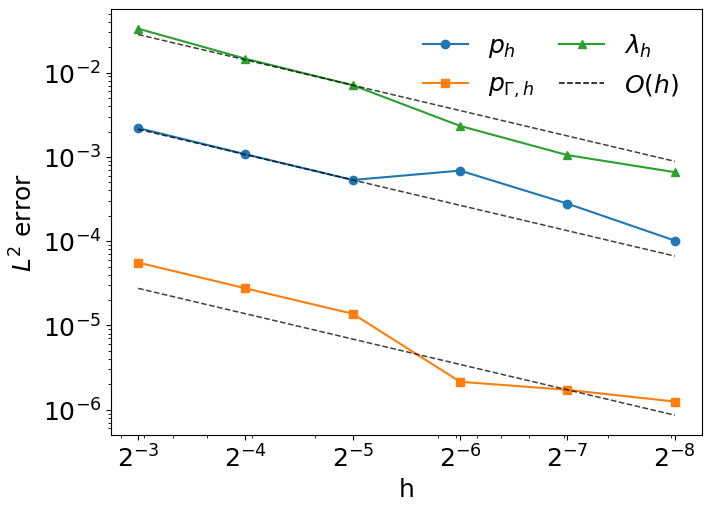

In [7]:
if CONV_PLOT and len(conv_results):
    try:
        import matplotlib.pyplot as plt
        from matplotlib.lines import Line2D

        # Select refinements to include in the convergence plot.
        # Use None, "all", or [] for every computed refinement; e.g. [5, 6, 7, 8].
        CONV_PLOT_REFS = [3, 4, 5, 6, 7, 8]

        # Dashed benchmark-line orders for each plotted quantity.
        CONV_BENCHMARK_ORDERS = {
            "p": 1,
            "p_Gamma": 1,
            "lambda": 1,
        }

        # Dashed benchmark-line styles for each plotted quantity.
        # e.g. "--", ":", "-.", or a custom dash tuple like (0, (3, 1, 1, 1)).
        CONV_BENCHMARK_LINESTYLES = {
            "p": "--",
            "p_Gamma": "--",
            "lambda": "--",
        }

        # Single neutral color for all reference lines (matches the legend).
        CONV_BENCHMARK_COLOR = "black"

        # Refinement where the benchmark lines are anchored.
        # None = coarsest plotted ref, one int = all lines, or a dict per series.
        CONV_BENCHMARK_ANCHOR_REF = {"p": 5, "p_Gamma": 7, "lambda": 5}

        def selected_convergence_rows(rows, selected_refs):
            if selected_refs is None:
                return list(rows)
            if isinstance(selected_refs, str):
                if selected_refs.lower() == "all":
                    return list(rows)
                requested = [int(ref.strip()) for ref in selected_refs.split(",") if ref.strip()]
            elif isinstance(selected_refs, (int, np.integer)):
                requested = [int(selected_refs)]
            else:
                requested = [int(ref) for ref in selected_refs]
            if not requested:
                return list(rows)

            available = {int(row["ref"]) for row in rows}
            missing = [ref for ref in requested if ref not in available]
            if missing:
                print(f"Convergence plot warning: refs not available in conv_results: {missing}")
            requested_set = set(requested)
            return [row for row in rows if int(row["ref"]) in requested_set]

        def benchmark_label(order):
            order = float(order)
            if np.isclose(order, 1.0):
                return r"$O(h)$"
            if np.isclose(order, round(order)):
                return rf"$O(h^{int(round(order))})$"
            return rf"$O(h^{{{order:g}}})$"

        def benchmark_anchor_ref(anchor_refs, series_name):
            if isinstance(anchor_refs, dict):
                return anchor_refs.get(series_name, anchor_refs.get("default", None))
            return anchor_refs

        def add_benchmark_line(ax, refs, hs, values, order, h_span=None, anchor_ref=None, legend_label=None, color="black", linestyle="--"):
            mask = np.isfinite(hs) & np.isfinite(values) & (hs > 0.0) & (values > 0.0)
            if np.count_nonzero(mask) < 1:
                return False
            refs_valid = refs[mask]
            h_valid = hs[mask]
            v_valid = values[mask]
            anchor = np.argmax(h_valid)
            if anchor_ref is not None:
                anchor_matches = np.flatnonzero(refs_valid == int(anchor_ref))
                if anchor_matches.size:
                    anchor = int(anchor_matches[0])
                else:
                    print(f"Benchmark anchor ref={anchor_ref} is not plotted; using coarsest plotted ref.")
            h0 = h_valid[anchor]
            v0 = v_valid[anchor]
            if np.count_nonzero(mask) >= 2:
                h_ref = np.array([h_valid.max(), h_valid.min()])
            elif h_span is not None:
                h_span = np.asarray(h_span, dtype=float)
                h_span = h_span[np.isfinite(h_span) & (h_span > 0.0)]
                h_ref = np.array([h_span.max(), h_span.min()]) if h_span.size >= 2 else h0 * np.array([2.0, 0.5])
            else:
                h_ref = h0 * np.array([2.0, 0.5])
            v_ref = v0 * (h_ref / h0)**float(order)
            ax.loglog(
                h_ref, v_ref, color=color, ls=linestyle, lw=1.1, alpha=0.75,
                label=legend_label if legend_label is not None else "_nolegend_",
            )
            return True

        plot_rows = selected_convergence_rows(conv_results, CONV_PLOT_REFS)
        if not plot_rows:
            raise ValueError("No convergence rows selected. Check CONV_PLOT_REFS.")

        refs = np.array([row["ref"] for row in plot_rows], dtype=int)
        hs = np.array([row["h"] for row in plot_rows], dtype=float)
        all_hs = np.array([row["h"] for row in conv_results], dtype=float)
        plot_series = [
            ("p", "err_pm", r"$p_h$", "o-"),
            ("p_Gamma", "err_pf", r"$p_{\Gamma,h}$", "s-"),
            ("lambda", "err_lam_int", r"$\lambda_h$", "^-"),
        ]

        fs = 18
        fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
        plotted = []
        for name, err_key, label, style in plot_series:
            values = np.array([row[err_key] for row in plot_rows], dtype=float)
            line, = ax.loglog(hs, values, style, label=label)
            plotted.append((name, label, values, line.get_color()))

        orders_used = []
        for name, label, values, color in plotted:
            order = CONV_BENCHMARK_ORDERS.get(name, 2.0)
            anchor_ref = benchmark_anchor_ref(CONV_BENCHMARK_ANCHOR_REF, name)
            linestyle = CONV_BENCHMARK_LINESTYLES.get(name, "--")
            if add_benchmark_line(ax, refs, hs, values, order, h_span=all_hs, anchor_ref=anchor_ref, legend_label=None, color=CONV_BENCHMARK_COLOR, linestyle=linestyle):
                orders_used.append(float(order))

        # One legend entry per distinct reference order (collapses to a single
        # "O(h)" when all curves share the same order). Neutral gray proxy.
        ref_proxies = [
            Line2D([0], [0], color=CONV_BENCHMARK_COLOR, ls="--", lw=1.1, label=benchmark_label(o))
            for o in sorted(set(orders_used))
        ]

        selected_refs = [int(row["ref"]) for row in plot_rows]
        print(f"Convergence plot refs: {selected_refs}")
        ax.invert_xaxis()
        ax.set_xticks(hs)
        ax.set_xticklabels([rf"$2^{{-{ref}}}$" for ref in refs])
        ax.set_xlabel("h", fontsize=fs)
        ax.set_ylabel(r"$L^2$ error", fontsize=fs)
        ax.tick_params(axis="both", which="both", labelsize=fs)
        # ax.set_title("2D point-trace LCG MMS convergence")
        ax.grid(False)
        handles, labels = ax.get_legend_handles_labels()
        handles += ref_proxies
        labels += [proxy.get_label() for proxy in ref_proxies]
        ax.legend(handles, labels, frameon=False, fontsize=fs, ncol=2, columnspacing=1.0, handlelength=1.8)
        plt.show()
    except Exception as exc:
        print(f"Convergence plot skipped: {exc}")
